# Playground for material data

In [1]:
import pandas as pd
from pymatgen.core import Structure
from pymatgen.vis.structure_vtk import StructureVis  # needs vtk
from pymatgen.io.ase import AseAtomsAdaptor
from ase.visualize import view
from src.dataLib.realCrystal import CrystalDataset
from src.dataLib.preprocessCSV import preprocess_matcsv
import src.dataLib.transform as T
import torch_geometric.transforms as PyGT
from torch_geometric.loader import DataLoader as PyGDataLoader
import os


Preprocess Carbon-24 CSV files

In [2]:
# preprocess the csv file
data_folder = "data/carbon-24"
# preprocess_matcsv(csv_folder=data_folder, splits=["train", "val", "test"])


Instantiate the Crystaline pytorch dataset 

In [3]:
transform = PyGT.Compose([
    T.ContinuousIntervalLengths(in_key="lengths", out_key="lengths_log"),
    T.ContinuousIntervalAngles(in_key="angles", out_key="angles_log"),
    T.FullyConnectedGraph(key="edge_index", len_from="pos"),
    T.Pos2Angle(in_key="pos", out_key="pos")
])
carbon_24_train = CrystalDataset(path=os.path.join(data_folder, "train.pt"), transform=transform)
carbon_24_train_loader = PyGDataLoader(carbon_24_train, batch_size=12, shuffle=True)
batch = next(iter(carbon_24_train_loader))

/Users/jizho/project_codes/diffusion-playground/src/dataLib/realCrystal.py:24: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([torch_geometric.data.data.DataEdgeAttr])` to allowlist this global.
  return fs.torch_load(path)


In [4]:
from src.diffusion import TDMDiffusion
import torch
device = "cuda" if torch.cuda.is_available() else "mps"

diffusion = TDMDiffusion(
    dim=3, 
    integrator_type="Euler", 
    trunc_n=13, 
    f_scale=2*torch.pi, 
    total_time=2.0, 
    simplified_param=True, 
    n_sigma_rs=2000, 
    zero_cog=True)
print(batch)
noised_sample_batch, score_batch, t_batch = diffusion.sample_forward_graph(batch, t_dist_kw="constant", v0_dist_kw="zero",constant_t = 2, return_time=True)


DataBatch(pos=[102, 3], h=[102], lengths=[12, 3], angles=[12, 3], lengths_log=[12, 3], angles_log=[12, 3], edge_index=[2, 814], x=[102, 3], batch=[102], ptr=[13])


Visualize the noised data, fractional coordinates

Data(pos=[8, 3], h=[8], lengths=[1, 3], angles=[1, 3], lengths_log=[1, 3], angles_log=[1, 3], edge_index=[2, 56], x=[8, 3])


/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_85845/1683457222.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(noised_graph_batch[3].x[:,0], noised_graph_batch[3].x[:,1], noised_graph_batch[3].x[:,2], c="steelblue", cmap="viridis")
/var/folders/__/63t897850y70y7c0ygvqpl6c0000gp/T/ipykernel_85845/1683457222.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(batch[3].x[:,0], batch[3].x[:,1], batch[3].x[:,2], c="red", cmap="viridis")


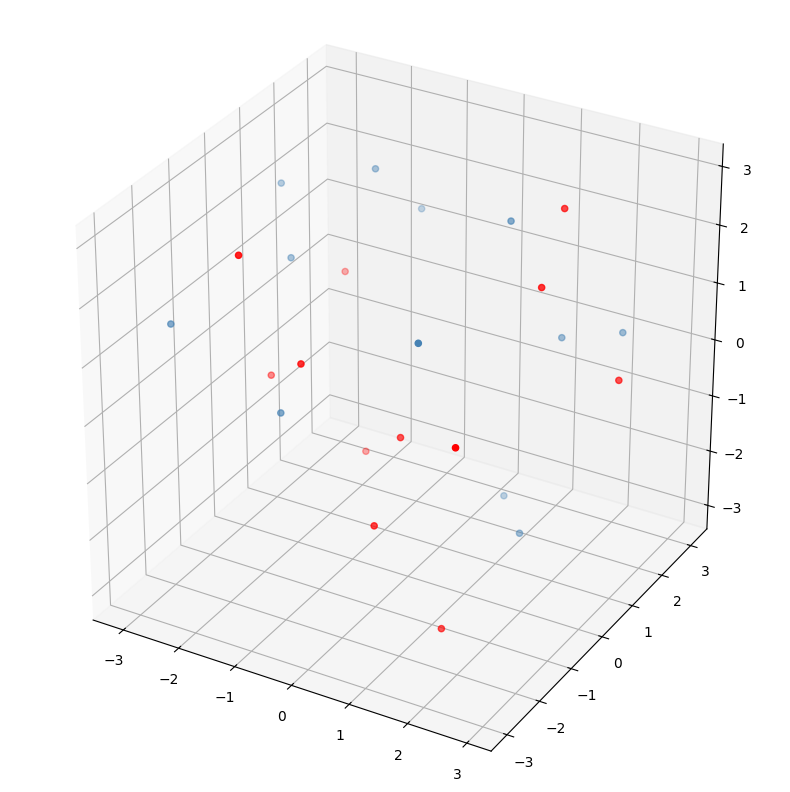

NGLWidget()

In [11]:
vt_batch, noised_graph_batch = noised_sample_batch

print(noised_graph_batch[2])
# visualize the noised points and the original points in 3D
import matplotlib.pyplot as plt
import nglview as nv
from src.dataLib.data_util import PyGData_to_AseAtoms, PyGData_to_Structure
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(noised_graph_batch[3].x[:,0], noised_graph_batch[3].x[:,1], noised_graph_batch[3].x[:,2], c="steelblue", cmap="viridis")
ax.scatter(batch[3].x[:,0], batch[3].x[:,1], batch[3].x[:,2], c="red", cmap="viridis")
# ax.scatter(vt_batch[:,0], vt_batch[:,1], c="green", cmap="viridis")
ax.set_aspect("equal")
plt.show()

structure = PyGData_to_Structure(noised_graph_batch[3])
atoms = PyGData_to_AseAtoms(noised_graph_batch[3])
viewer = nv.show_ase(atoms)
viewer.clear_representations()
viewer.add_spacefill(radius_scale=0.5)
viewer.add_unitcell()
viewer




In [12]:
structure = PyGData_to_Structure(batch[3])
atoms = PyGData_to_AseAtoms(batch[3])
viewer = nv.show_ase(atoms)
viewer.clear_representations()
viewer.add_spacefill(radius_scale=0.5)
viewer.add_unitcell()
viewer

NGLWidget()